# Phase III: Envelope optimization integrated into surroundings

**Building:** H Building · **Model:** `models/h_envelope_wwr15.idf` · **Weather:** `weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw` · **Output:** `results/h_envelope_wwr15_results.csv`

Multi-objective optimization (NSGA-II via BESOS) minimizing cooling and heating demand with nine envelope and natural-ventilation variables. Run this notebook from its own folder (paths are relative to `notebooks/`).

## Envelope optimization


### *Import* of libraries

In [1]:
from besos import eppy_funcs as ef
from besos import eplus_funcs as ep
from besos.problem import EPProblem
from besos.objectives import *
from besos.evaluator import EvaluatorEP
from besos.parameters import wwr, RangeParameter, FieldSelector, FilterSelector, GenericSelector, Parameter, expand_plist
from besos.optimizer import NSGAII, SPEA2
from platypus.evaluator import MapEvaluator
import platypus
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dask.distributed import Client

### Simulation Model

In [2]:
building = ef.get_building('../models/h_envelope_wwr15.idf') # Loading the E+ model;

### Variables

In [3]:
parameters = []

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_north",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - North Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_south",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - South Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_east",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - East Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_west",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - West Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Rockwool_roof",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='IT - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.0001, max_val=0.15)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Ext mortar",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Walls',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="MATERIAL",             # Class of E+;
                    object_name="Fibercement tile",    # Object name;
                    field_name="Solar Absorptance", # Object field;
                ),
                name='SA - Ext. Roof',
                value_descriptor=RangeParameter(min_val=0.2, max_val=0.8)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="WINDOWMATERIAL:GLAZING",   # Class of E+;
                    object_name="Clear 3mm",    # Object name;
                    field_name="Thickness", # Object field;
                ),
                name='Glazing - Thickness',
                value_descriptor=RangeParameter(min_val=0.003, max_val=0.01)      # Range
                )
            )

parameters.append(
            Parameter(
                selector=FieldSelector(
                    class_name="SCHEDULE:COMPACT",             # Class of E+;
                    object_name="VN_19",    # Object name;
                    field_name="Field 4", # Object field;
                ),
                name='AFN - Setpoint',
                value_descriptor=RangeParameter(min_val=18, max_val=25)      # Range
                )
            )


### Selection of the analysis objectives

In [4]:
demanda_resf = MeterReader('DistrictCooling:HVAC', name="Cooling demand (kWh/m²)")
demanda_aquec = MeterReader('DistrictHeating:HVAC', name="Heating demand (kWh/m²)")
EPobjectives = [demanda_resf,demanda_aquec] # cooling and heating as objectives;
problem = EPProblem(parameters, EPobjectives)  # Creating an instance of the problem;

### NSGA-II evaluation function and parameters definition + runtime

In [5]:
evaluator = EvaluatorEP(problem, building, epw="../../../weather/BRA_RS_Passo.Fundo.869630_TMYx.2007-2021.epw")   # Evaluation function with the problem and the model;
startTime = datetime.now()
results = NSGAII(evaluator, evaluations=500, population_size=100)   # running the NSGA-II;
print(datetime.now() - startTime)

1 day, 9:06:51.902714


### Results

In [6]:
results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.147467,0.148789,0.131077,0.141074,0.149511,0.760489,0.761045,0.007715,24.959862,1.894092e+11,1.059725e+09,0,True
1,0.018646,0.000191,0.001192,0.013842,0.041086,0.200490,0.310638,0.005060,19.049691,8.972159e+10,1.018287e+11,0,True
2,0.007543,0.050344,0.013095,0.039507,0.002300,0.202864,0.201342,0.004342,20.774725,9.078455e+10,8.873179e+10,0,True
3,0.003070,0.007606,0.005974,0.018721,0.122962,0.206016,0.243258,0.004733,21.095086,9.096190e+10,4.723142e+10,0,True
4,0.142469,0.144321,0.118538,0.119134,0.148912,0.658808,0.523692,0.009991,22.630526,1.449624e+11,1.480189e+09,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.115349,0.123094,0.143997,0.110246,0.148903,0.529124,0.426478,0.006242,24.047804,1.761899e+11,1.709526e+09,0,False
96,0.002655,0.007730,0.001574,0.097659,0.127736,0.210574,0.356075,0.004893,22.603341,9.707010e+10,4.015224e+10,0,False
97,0.027964,0.025377,0.088859,0.005437,0.111373,0.268790,0.243258,0.004731,21.109015,1.042798e+11,2.511620e+10,0,False
98,0.000874,0.027360,0.096852,0.005437,0.109227,0.271716,0.204102,0.004766,21.046550,1.004578e+11,3.362426e+10,0,False


### *Plot* of the results (heating and cooling demand in kWh/m²·year)

In [7]:
import math
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']*pow(10,-9))
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']*pow(10,-9))
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/0.0036)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/0.0036)
results['Heating demand (kWh/m²)'] = (results['Heating demand (kWh/m²)']/876.15)
results['Cooling demand (kWh/m²)'] = (results['Cooling demand (kWh/m²)']/876.15)

results

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.147467,0.148789,0.131077,0.141074,0.149511,0.760489,0.761045,0.007715,24.959862,60.050968,0.335979,0,True
1,0.018646,0.000191,0.001192,0.013842,0.041086,0.200490,0.310638,0.005060,19.049691,28.445660,32.284136,0,True
2,0.007543,0.050344,0.013095,0.039507,0.002300,0.202864,0.201342,0.004342,20.774725,28.782663,28.131848,0,True
3,0.003070,0.007606,0.005974,0.018721,0.122962,0.206016,0.243258,0.004733,21.095086,28.838891,14.974420,0,True
4,0.142469,0.144321,0.118538,0.119134,0.148912,0.658808,0.523692,0.009991,22.630526,45.959418,0.469285,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.115349,0.123094,0.143997,0.110246,0.148903,0.529124,0.426478,0.006242,24.047804,55.859886,0.541994,0,False
96,0.002655,0.007730,0.001574,0.097659,0.127736,0.210574,0.356075,0.004893,22.603341,30.775457,12.730013,0,False
97,0.027964,0.025377,0.088859,0.005437,0.111373,0.268790,0.243258,0.004731,21.109015,33.061235,7.962932,0,False
98,0.000874,0.027360,0.096852,0.005437,0.109227,0.271716,0.204102,0.004766,21.046550,31.849494,10.660357,0,False


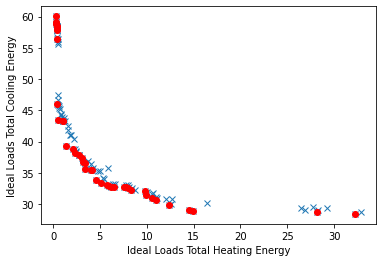

In [8]:
optres = results.loc[results['pareto-optimal']==True,:] # pareto-optimal
plt.plot(results['Heating demand (kWh/m²)'], results['Cooling demand (kWh/m²)'],'x') # Plot all results in 'x'
plt.plot(optres['Heating demand (kWh/m²)'], optres['Cooling demand (kWh/m²)'],'ro') # Plot of the best solutions in red
plt.xlabel('Ideal Loads Total Heating Energy')
plt.ylabel('Ideal Loads Total Cooling Energy')
plt.savefig("../results/h_envelope_wwr15_pareto.png")
#plt.axis([0.00,0.08,0.0,1.6]) #Set the dimension of the chart

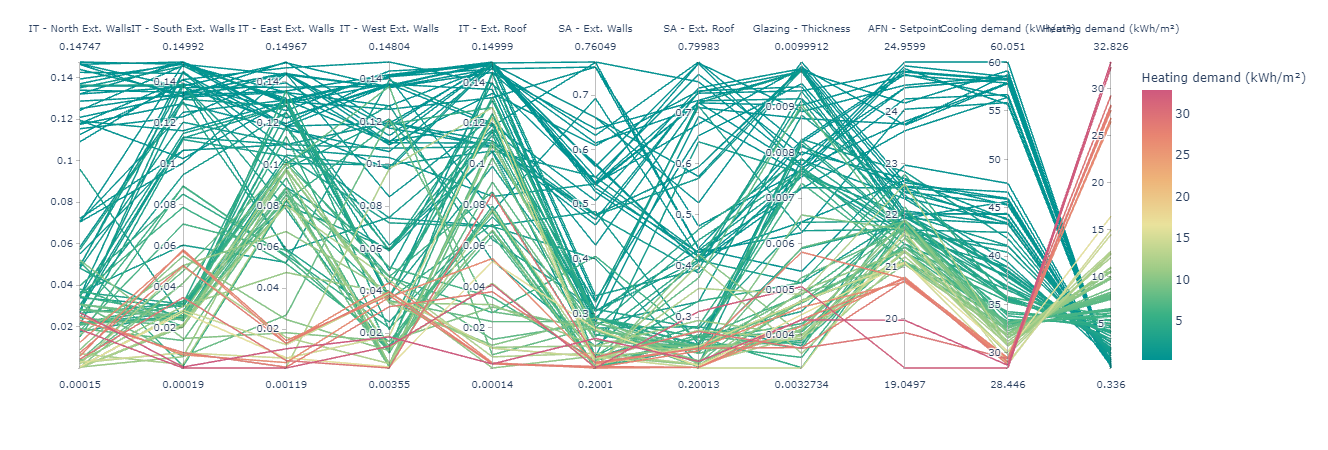

In [9]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.express as px
fig = px.parallel_coordinates(results,color="Heating demand (kWh/m²)", dimensions=["IT - North Ext. Walls","IT - South Ext. Walls","IT - East Ext. Walls","IT - West Ext. Walls","IT - Ext. Roof","SA - Ext. Walls","SA - Ext. Roof", "Glazing - Thickness", "AFN - Setpoint", "Cooling demand (kWh/m²)","Heating demand (kWh/m²)" ],
    color_continuous_scale=px.colors.diverging.Temps)
fig.show()

In [10]:
optres

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
0,0.147467,0.148789,0.131077,0.141074,0.149511,0.760489,0.761045,0.007715,24.959862,60.050968,0.335979,0,True
1,0.018646,0.000191,0.001192,0.013842,0.041086,0.200490,0.310638,0.005060,19.049691,28.445660,32.284136,0,True
2,0.007543,0.050344,0.013095,0.039507,0.002300,0.202864,0.201342,0.004342,20.774725,28.782663,28.131848,0,True
3,0.003070,0.007606,0.005974,0.018721,0.122962,0.206016,0.243258,0.004733,21.095086,28.838891,14.974420,0,True
4,0.142469,0.144321,0.118538,0.119134,0.148912,0.658808,0.523692,0.009991,22.630526,45.959418,0.469285,0,True
5,0.146646,0.137386,0.137466,0.136484,0.149770,0.522990,0.410348,0.008221,24.720122,56.437303,0.422222,0,True
6,0.135025,0.147823,0.131997,0.035694,0.144716,0.292105,0.246219,0.007842,22.318589,39.369703,1.366223,0,True
7,0.000148,0.021581,0.080018,0.045066,0.005600,0.227114,0.207247,0.003984,21.319348,29.838093,12.421949,0,True
8,0.055094,0.106675,0.109580,0.119562,0.108481,0.480958,0.594375,0.009869,22.084981,43.307665,1.094333,0,True
9,0.000610,0.028487,0.012524,0.038845,0.009904,0.220234,0.200128,0.003273,21.688801,28.997673,14.507206,0,True


In [11]:
results.to_csv('../results/h_envelope_wwr15_results.csv')

In [12]:
min_idealloads = results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']
min_idealloads = min_idealloads[min_idealloads == min_idealloads.min()]
bestone = results[(results['Cooling demand (kWh/m²)']+results['Heating demand (kWh/m²)']) == min_idealloads.min()]
bestone

,IT - North Ext. Walls,IT - South Ext. Walls,IT - East Ext. Walls,IT - West Ext. Walls,IT - Ext. Roof,SA - Ext. Walls,SA - Ext. Roof,Glazing - Thickness,AFN - Setpoint,Cooling demand (kWh/m²),Heating demand (kWh/m²),violation,pareto-optimal
12,0.039778,0.085234,0.056063,0.022484,0.067062,0.200114,0.24193,0.003874,21.827444,33.838046,4.608451,0,True
